# setup

In [3]:
import network

import torch
import torch.nn as nn
import torch.nn.functional as F

# Unlike object, with SimpleNamespace you can add and remove attributes.
from types import SimpleNamespace 

import numpy as np

import random

# set the network size, to feed into the 1-layer network class

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

m = 100
n = 50

# Set seed
seed = 1
network.set_random_mode(True, seed)

init_parameters = SimpleNamespace()
init_parameters.m = m # input dimension
init_parameters.n = n # measurement dimension
init_parameters.seed = seed

# the measurement matrix: randomly initialized
init_parameters.W = torch.randn(n,m).to(device)/torch.sqrt(torch.tensor(n))

store_image = True

[Random Mode] Deterministic with seed 1


## save the parameters

In [5]:
import pickle
import os


weight_folder = f'weights/m_{m}_n_{n}_s_{seed}'
os.makedirs(weight_folder, exist_ok=True)

param_path = f'{weight_folder}/init_params.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(init_parameters, f)

# create the network

In [6]:
enose_network = network.enose(init_parameters)
print(enose_network.m)

100


## print the architecture of the network

In [7]:
for name, param in enose_network.named_parameters():
    print(f"{name}: {param.shape}")

fc1.weight: torch.Size([1, 100])
fc1.bias: torch.Size([1])


# create the dataset and creating a bi-directional dataset (NEW: 05/27)

In [8]:
num_data=10000
training_frac=0.8
threshold=0.1
x_hat = threshold
num_training = int(num_data*training_frac)

# NEW (05/27/2025): allowing for bidirectional and custom data intervals
bidir_lower_bound = 0
bidir_upper_bound = 1

dataset = network.generate_custom_dataset(m, n, device, num_data, training_frac, threshold, bidir_lower_bound, bidir_upper_bound)
print(dataset)


# training dataset
train_conc = dataset.train_conc
train_labels = dataset.train_labels

# test dataset
test_conc = dataset.test_conc
test_labels = dataset.test_labels

test_batch_size = 20

# initial accuracy
initial_accuracy = network.evaluate_random_batch(enose_network, dataset, test_batch_size=20, threshold=0.1)
print(initial_accuracy)


namespace(odor_conc=tensor([[8.2214e-01, 9.6960e-01, 6.4312e-01,  ..., 5.5187e-01, 6.6746e-01,
         8.9681e-01],
        [4.2289e-04, 9.5209e-01, 2.0996e-01,  ..., 7.6644e-01, 4.9177e-01,
         1.9550e-01],
        [5.7868e-01, 5.0164e-01, 2.7016e-01,  ..., 2.0105e-02, 4.9284e-01,
         5.7008e-01],
        ...,
        [6.6965e-01, 8.0078e-01, 3.5354e-01,  ..., 6.7256e-01, 9.1264e-01,
         3.7700e-01],
        [4.5472e-01, 6.0969e-01, 7.7121e-01,  ..., 3.7016e-01, 3.6528e-01,
         1.7203e-02],
        [6.1884e-01, 3.9933e-01, 2.2731e-01,  ..., 1.1388e-01, 9.8578e-01,
         9.0133e-01]], device='mps:0'), labels=tensor([1, 1, 1,  ..., 1, 1, 1], device='mps:0'), train_conc=tensor([[8.2214e-01, 9.6960e-01, 6.4312e-01,  ..., 1.3684e-01, 1.7382e-01,
         8.9114e-01],
        [4.2289e-04, 9.5209e-01, 2.0996e-01,  ..., 9.0057e-01, 9.7757e-01,
         8.9252e-01],
        [5.7868e-01, 5.0164e-01, 2.7016e-01,  ..., 3.5945e-01, 4.2700e-01,
         6.9924e-01],
        

# optimize the parameters using cross entropy

In [9]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(enose_network.parameters(), lr = 0.001)
lr=0.001

batch_size = 10 # having a small batch_size helps the model generalize to real life relationship (flat minimizer) --> maybe try 16?

steps = 10000
loss_vec = torch.zeros(steps)

test_interval = 50 # to make sure that all the test data are used multiple times
print_interval = 50 # how often to print the accuracies and loss in terminal
test_batch_size = 20 
accuracy_vec = torch.zeros(steps // test_interval)

loss_vec, accuracy_vec = network.train_model(
    enose_network,
    criterion,
    optimizer,
    lr,
    train_conc,
    train_labels,
    test_conc,
    test_labels,
    num_data,
    num_training,
    steps,
    batch_size,
    test_interval,
    print_interval,
    test_batch_size,
    device
)
                

[Step 0] Accuracy: 0.7500 | Train Loss: 0.5709
[Step 50] Accuracy: 0.9000 | Train Loss: 0.1524
[Step 100] Accuracy: 1.0000 | Train Loss: 0.3083
[Step 150] Accuracy: 0.9000 | Train Loss: 0.3206
[Step 200] Accuracy: 0.9000 | Train Loss: 0.1189
[Step 250] Accuracy: 0.8500 | Train Loss: 0.3389
[Step 300] Accuracy: 0.9500 | Train Loss: 0.1199
[Step 350] Accuracy: 0.9500 | Train Loss: 0.7100
[Step 400] Accuracy: 0.8000 | Train Loss: 0.7675
[Step 450] Accuracy: 0.8500 | Train Loss: 0.0863
[Step 500] Accuracy: 0.7000 | Train Loss: 0.0959
[Step 550] Accuracy: 1.0000 | Train Loss: 0.1331
[Step 600] Accuracy: 0.8500 | Train Loss: 0.2988
[Step 650] Accuracy: 0.9000 | Train Loss: 0.2468
[Step 700] Accuracy: 0.9500 | Train Loss: 0.3309
[Step 750] Accuracy: 1.0000 | Train Loss: 0.2611
[Step 800] Accuracy: 0.9000 | Train Loss: 0.0920
[Step 850] Accuracy: 0.8000 | Train Loss: 0.4904
[Step 900] Accuracy: 0.9000 | Train Loss: 0.0791
[Step 950] Accuracy: 0.9000 | Train Loss: 0.1062
[Step 1000] Accuracy: 1

## save the trained parameters

In [10]:
# to save the model weights
torch.save(enose_network.state_dict(), f"{weight_folder}/model_weights.pth")

In [11]:
accuracy_vec

tensor([0.7500, 0.9000, 1.0000, 0.9000, 0.9000, 0.8500, 0.9500, 0.9500, 0.8000,
        0.8500, 0.7000, 1.0000, 0.8500, 0.9000, 0.9500, 1.0000, 0.9000, 0.8000,
        0.9000, 0.9000, 1.0000, 0.8500, 0.8500, 1.0000, 0.8000, 0.7500, 0.8500,
        0.8500, 0.8500, 0.9000, 0.9000, 0.9000, 0.9000, 0.9000, 0.8000, 1.0000,
        0.9000, 0.8000, 0.7500, 0.9000, 0.8500, 0.9500, 0.8500, 0.7500, 0.9000,
        1.0000, 0.9500, 0.9500, 0.9000, 0.9500, 0.8500, 0.9000, 0.9000, 0.8500,
        0.9500, 0.8000, 0.9500, 0.8000, 0.8500, 0.8500, 0.8000, 0.9000, 0.9000,
        0.9000, 0.9500, 0.7500, 0.8500, 0.8500, 0.9500, 0.9500, 0.9500, 0.7500,
        0.9000, 0.8500, 0.8000, 0.8500, 0.8000, 1.0000, 0.9500, 0.9500, 0.8000,
        0.9500, 0.9000, 0.9500, 0.9000, 0.9000, 0.9000, 0.9000, 1.0000, 0.9500,
        0.8000, 0.8500, 0.9500, 0.7500, 0.8500, 1.0000, 0.8500, 0.9000, 1.0000,
        1.0000, 0.9000, 0.9500, 0.8000, 0.8000, 0.9500, 0.9000, 0.9000, 0.8500,
        1.0000, 1.0000, 0.8000, 0.7500, 

## save mean accuracy, to compare with the accuracy after weight pertubation

In [12]:
num_step = len(accuracy_vec)
mean_accuracy = torch.mean(accuracy_vec[num_step//2:-1])

param_path = f'{weight_folder}/mean_accuracy.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(mean_accuracy, f)
    
print(num_step)
mean_accuracy

200


tensor(0.9071)

# plot the training loss and test accuracy

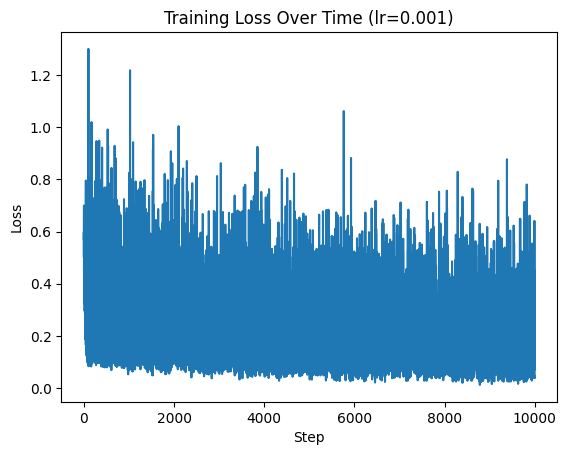

In [13]:
# Plot the loss curve and save (optional)

import matplotlib.pyplot as plt
import os

plt.plot(loss_vec)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Time (lr=" + str(lr) + ")")
# Make sure the folder exists
if store_image:
    folder = f'figures/m_{m}_n_{n}_s_{seed}'
    os.makedirs(folder, exist_ok=True)
    plt.savefig(f"{folder}/loss.pdf") 
plt.show()

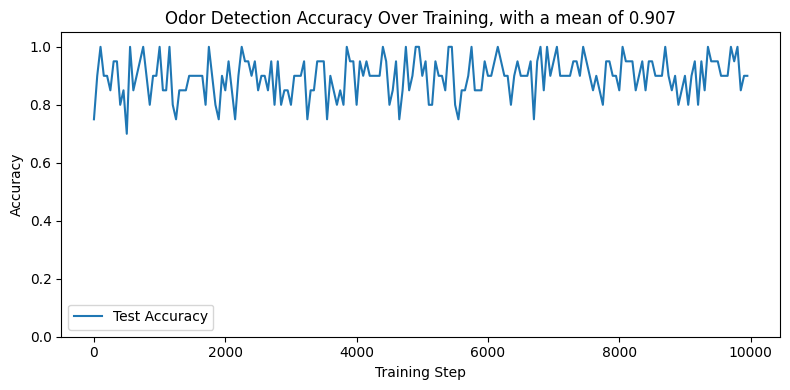

In [14]:
# Plot the test accuracy curve

import matplotlib.pyplot as plt

# mean_accuracy = torch.mean()

plt.figure(figsize=(8, 4))
plt.plot(torch.arange(0, steps, 50), accuracy_vec, label='Test Accuracy')
plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title(f"Odor Detection Accuracy Over Training, with a mean of {mean_accuracy:.3f}")
plt.ylim(0, 1.05)
# plt.grid(True)
plt.legend()
plt.tight_layout()
if store_image:
    plt.savefig(f"{folder}/accuracy.pdf")

plt.show()

# plot the weight matrices

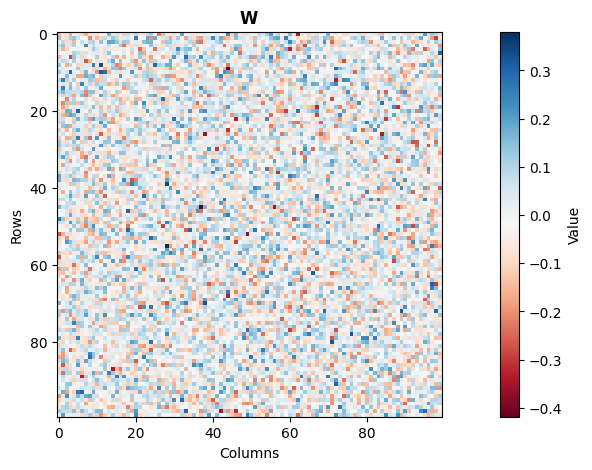

In [15]:
import torch
import matplotlib.pyplot as plt
W = enose_network.W.cpu().numpy()
# Plot using imshow
plt.figure(figsize=(15, 5))
plt.imshow(W, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W.pdf", bbox_inches='tight')
plt.show()

## plot the matrices

In [16]:
enose_network.fc1.bias

Parameter containing:
tensor([0.0443], device='mps:0', requires_grad=True)

1
-0.010084490785922405


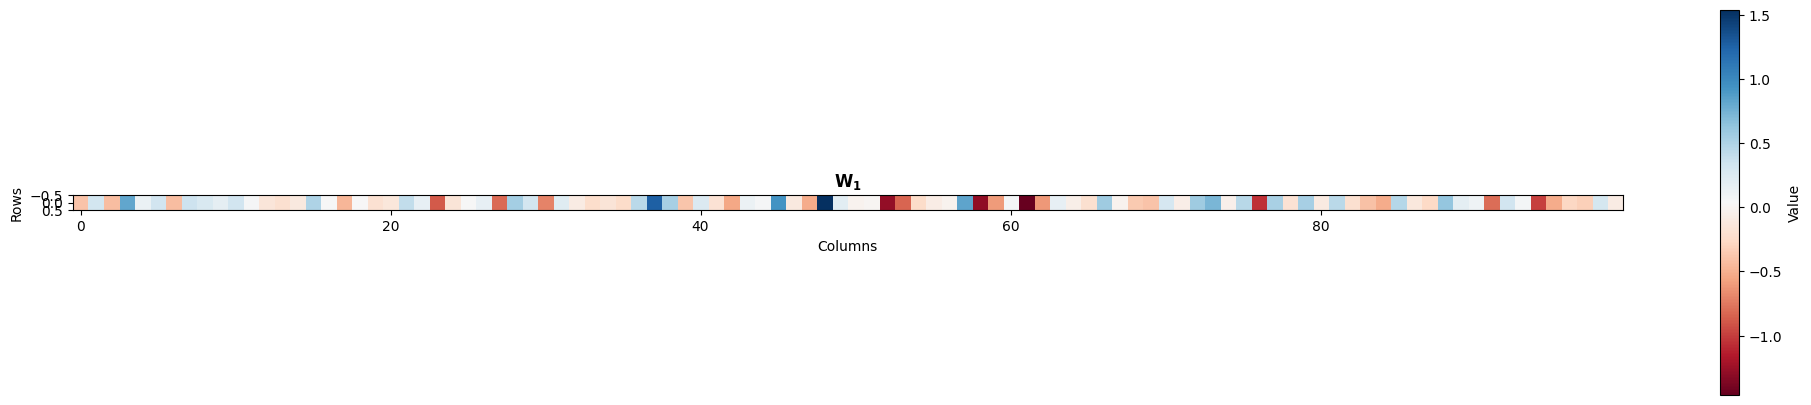

In [17]:
import torch
import matplotlib.pyplot as plt

W1 = enose_network.fc1.weight.detach().cpu().numpy()
b1 = enose_network.fc1.bias.detach().cpu().numpy()
print(b1.size)

W_h = W1 @ W
x1_hat_dagger = -b1[0]/W_h[0,0].item()
print(x1_hat_dagger)

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W1, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W1.pdf", bbox_inches='tight')
plt.show()

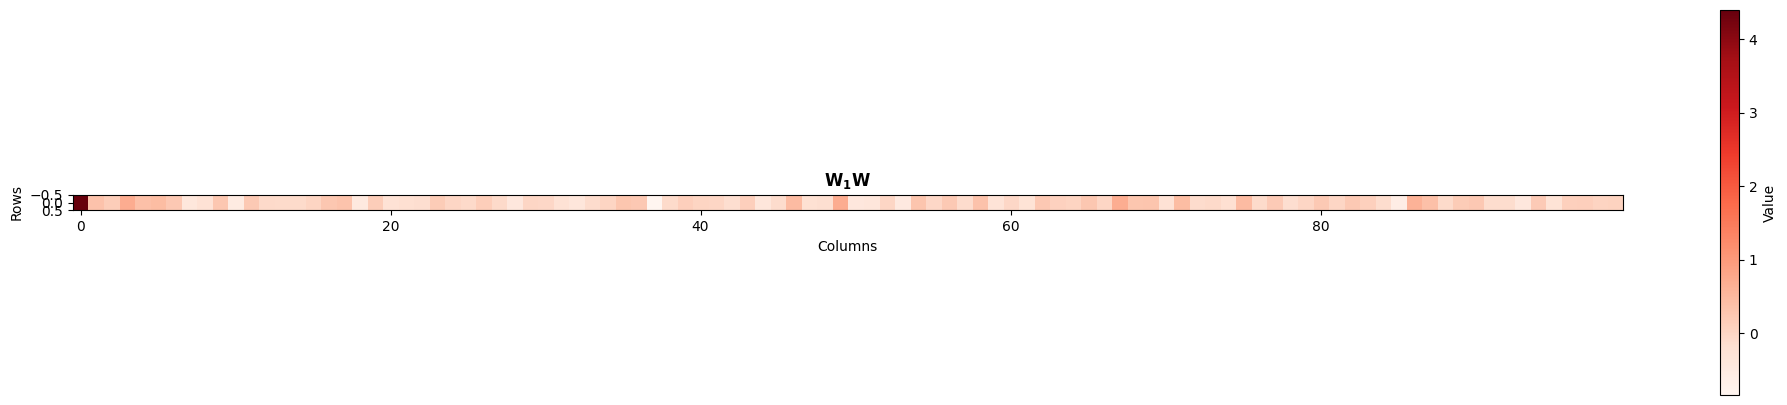

[ 4.39740658e+00  3.36397320e-01  1.47917643e-01  7.04644978e-01
  3.73736650e-01  4.32784975e-01  2.41236269e-01 -3.89116079e-01
 -2.62351215e-01  2.60036021e-01 -5.48480034e-01  2.20323280e-01
 -6.56193420e-02 -9.73733440e-02 -9.37763229e-02  2.66814092e-03
  2.61524618e-01  3.19026679e-01 -4.60571051e-01  1.45601794e-01
 -2.43635312e-01 -1.98560342e-01 -1.51170552e-01  1.80229843e-01
 -1.60484742e-02 -7.20207691e-02  1.42343983e-01 -6.21711761e-02
 -4.21252161e-01 -1.19499667e-02 -2.50184499e-02 -2.63110340e-01
 -3.77495021e-01 -1.11197315e-01  2.17707325e-02  2.83385456e-01
  2.40578726e-01 -8.36303413e-01 -8.80365819e-02  1.07384354e-01
  4.71696258e-03 -2.18060031e-05 -1.55996114e-01  1.10718548e-01
 -3.72692227e-01 -1.11943111e-01  4.65365082e-01 -2.13885784e-01
 -1.68034241e-01  7.06531525e-01 -4.27191079e-01 -3.68842244e-01
 -1.58572588e-02 -4.87347811e-01  2.89341092e-01 -3.22434492e-02
  2.15878502e-01 -1.14293985e-01  3.47212076e-01 -2.90089756e-01
 -3.00354827e-02 -2.70895

In [18]:
import torch
import matplotlib.pyplot as plt

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W_h , cmap='Reds', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1 W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W_h.pdf")
# plt.savefig("figures/W_h.pdf")
plt.show()
plt.close()

# to verify that the first element dominates
print(W_h[0]) 

# plot the simplified 1-D curve, since the first element dominates

In [19]:
x_hat = threshold
print(x_hat)
print(x1_hat_dagger)

0.1
-0.010084490785922405


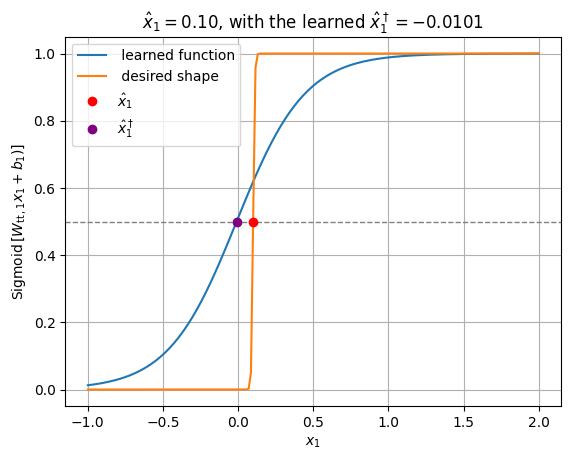

In [20]:
# x = torch.linspace(0, 1, 200)
x = torch.linspace(-1, 2, 200)

y = torch.sigmoid( W_h[0][0]*x + b1 )
y_2 = torch.sigmoid( 200*(x - x_hat) )
plt.plot(x, y, label =' learned function')
plt.plot(x, y_2, label = ' desired shape')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
plt.plot(x_hat, 0.5, 'o', color='red', label=r'$\hat{x}_1$')
plt.plot(x1_hat_dagger, 0.5, 'o', color='purple', label=r'$\hat{x}_1^\dagger$')


plt.title(fr'$\hat{{x}}_1 = {x_hat:.2f} $, with the learned $\hat{{x}}_1^\dagger = {x1_hat_dagger:.4f} $')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$\operatorname{Sigmoid}\left[ W_{\operatorname{tt},1} x_1 + b_1 ) \right]$')
plt.legend()
plt.grid(True)
if store_image:
    plt.savefig(f"{folder}/pickup_first_dim.pdf", bbox_inches='tight')
plt.show()

## verify that the analytical full expression is correct; compare the full expression versus the simplified 1-D expression

In [21]:
# the test dataset
test_idx = torch.randint(0, num_data - num_training, (test_batch_size,))
x_test = test_conc[:, test_idx]
y_test = test_labels[test_idx].view(-1, 1).float()

In [22]:
## ===== to check the analytical expression matches with the network expression =====

W_h_tensor = torch.tensor(W_h, dtype=torch.float32, device=x_test.device)
bias_final = torch.tensor(b1, dtype=torch.float32, device=x_test.device)

# the network expression
with torch.no_grad():
    enose_network.eval()
    pred = enose_network(x_test)
    predicted_labels = (pred > 0.5).float()
    accuracy = (predicted_labels == y_test).float().mean().item()
    # accuracy_vec[ steps // test_interval] = accuracy
    print(f"Test Accuracy = {accuracy:.4f}")

print(pred.mT)

# the analytical expression
out1 = torch.sigmoid(W_h_tensor @ x_test + bias_final)  # shape: [output_dim, num_samples]
out1 = out1[0]
print(out1)

Test Accuracy = 0.8000
tensor([[0.8381, 0.9894, 0.9886, 0.8128, 0.7874, 0.8872, 0.7997, 0.9878, 0.6794,
         0.7500, 0.9814, 0.9067, 0.5581, 0.9925, 0.9958, 0.8039, 0.9889, 0.9920,
         0.8871, 0.9944]], device='mps:0')
tensor([0.8381, 0.9894, 0.9886, 0.8128, 0.7874, 0.8872, 0.7997, 0.9878, 0.6794,
        0.7500, 0.9814, 0.9067, 0.5581, 0.9925, 0.9958, 0.8039, 0.9889, 0.9920,
        0.8871, 0.9944], device='mps:0')


In [23]:
out2 = torch.sigmoid(W_h_tensor[0][0] * x_test[0, :] + bias_final)  # shape: [num_samples]
out3 = torch.sigmoid(W_h_tensor[0][0] * (x_test[0, :] - x1_hat_dagger) )  # shape: [num_samples]
out4 = torch.sigmoid(W_h_tensor[0][0] * (x_test[0, :] - x_hat) )  # shape: [num_samples]

accr_1 = ((out1 > 0.5).float().T == y_test.squeeze()).float().mean().item()
accr_2 = ((out2 > 0.5).float().T == y_test.squeeze()).float().mean().item()

/var/folders/2w/xwcnb67d2wq2rf_47cyk6vpr0000gn/T/ipykernel_24517/4066574986.py:5: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3687.)
  accr_1 = ((out1 > 0.5).float().T == y_test.squeeze()).float().mean().item()


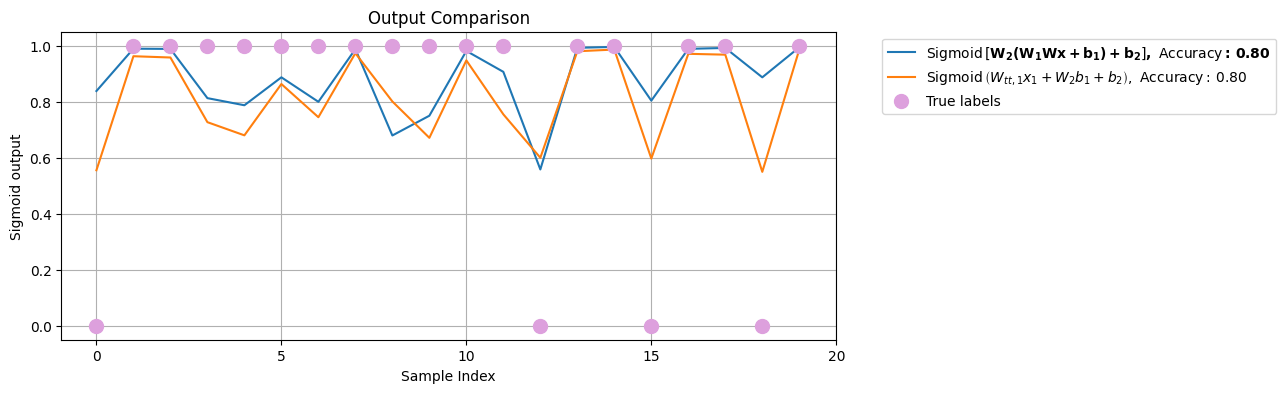

In [24]:
import torch
import matplotlib.pyplot as plt

# Plot comparison
plt.figure(figsize=(10, 4))
plt.plot(out1.cpu(), label=fr'$\operatorname{{Sigmoid}}\left[\bf W_2 (W_1 Wx +b_1)+b_2 \right],\ \operatorname{{Accuracy: }} {accr_1:.2f} $')
plt.plot(out2.cpu(), label=fr'$\operatorname{{Sigmoid}}\left(W_{{tt,1}} x_1 + W_2b_1+b_2 \right),\ \operatorname{{Accuracy: }} {accr_2:.2f} $')
# plt.plot(out3.cpu(), label=fr'$\operatorname{{Sigmoid}}\left[\bf W_2 (W_1 Wx +b_1)+b_2 \right],\ \operatorname{{Accuracy: }} {accr_1:.2f} $')
# plt.plot(out4.cpu(), label=fr'$\operatorname{{Sigmoid}}\left(W_{{tt,1}} x_1 + W_2b_1+b_2 \right),\ \operatorname{{Accuracy: }} {accr_2:.2f} $')
# plt.plot(log_out2.cpu(), label=r'$\operatorname{Sigmoid}$', linestyle='--')
plt.plot(y_test.cpu(), label = 'True labels', linestyle='none', marker='.', markersize = 20, color='plum')
plt.title("Output Comparison")
plt.xlabel("Sample Index")
plt.xticks(ticks=range(0, len(y_test)+1,5), labels=range(0, len(y_test)+1,5))
plt.ylabel("Sigmoid output")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
if store_image:
    plt.savefig(f"{folder}/Output_Comparison.pdf", bbox_inches='tight')
plt.show()